# Product-Image Classifier (CNN)

This notebook trains a small CNN to sort product photos into **Apparel**, **Electronics**, and **Home**.

**How to run this:**
1. Open this file in Google Colab (upload it, or once it's on GitHub: File → Open Notebook → GitHub).
2. Go to `Runtime -> Change runtime type -> Hardware accelerator -> GPU`, then save.
3. Run the cells top to bottom, one at a time — read the comments as you go.

We're using **TensorFlow / Keras**: it handles the training loop for you (`model.fit(...)`), so there's less boilerplate to learn before you see results.

In [3]:
# Quick check that Colab actually gave us a GPU.
# If this prints an empty list, go to Runtime -> Change runtime type -> GPU, then re-run this cell.
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 1: Get your data into Colab

You've already downloaded a Kaggle e-commerce product image set and organized it on your laptop into:

```
data/raw/
├── train/
│   ├── Apparel/
│   ├── Electronics/
│   └── Home/
└── val/
    ├── Apparel/
    ├── Electronics/
    └── Home/
```

Colab runs on Google's servers, so it can't see files on your laptop — we need to upload them.

**Before running the next cell:** on your laptop, right-click the `raw` folder (inside `data/`) and compress it into a file called `data_raw.zip`.

In [4]:
from google.colab import files
files.upload()  # select data_raw.zip when prompted — this may take a few minutes depending on dataset size

!mkdir -p data/raw
!unzip -q data_raw.zip -d data/raw
!echo "Done. Folder structure:"
!find data/raw -maxdepth 2 -type d

Saving data_raw.zip to data_raw (1).zip
replace data/raw/raw/train/Apparel/CLOTHING_ACCESSORIES_JEWELLERY/14587_CLOTHI_val.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Done. Folder structure:
data/raw
data/raw/raw
data/raw/raw/train
data/raw/raw/val


**Check the output above.** You should see `data/raw/train/Apparel`, `data/raw/train/Electronics`, `data/raw/train/Home`, and the same three under `val`. If the paths look different (e.g. there's an extra `raw` folder nested inside), adjust `DATA_DIR` in the next cell to match.

## Step 2: Load the images

Keras has a built-in helper, `image_dataset_from_directory`, that reads images straight out of folders like ours — it automatically treats each subfolder name (`Apparel`, `Electronics`, `Home`) as a class label. This is exactly why we organized the data that way.

In [9]:
DATA_DIR = "data/raw/raw"
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
SEED = 123  # must match between the two calls below so Keras splits identically both times

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/train",       # note: both point at train/ now — val/ is a duplicate, so we ignore it
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/train",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

class_names = train_ds.class_names
print("Classes found:", class_names)

Found 1074 files belonging to 3 classes.
Using 860 files for training.
Found 1074 files belonging to 3 classes.
Using 214 files for validation.
Classes found: ['Apparel', 'Electronics', 'Home']


## Step 3: Look at what we actually have

Before building anything, it's worth sanity-checking the data — how many images per class (a big imbalance would need fixing), and what the images actually look like.

Apparel: 1 images
Electronics: 1 images
Home: 1 images


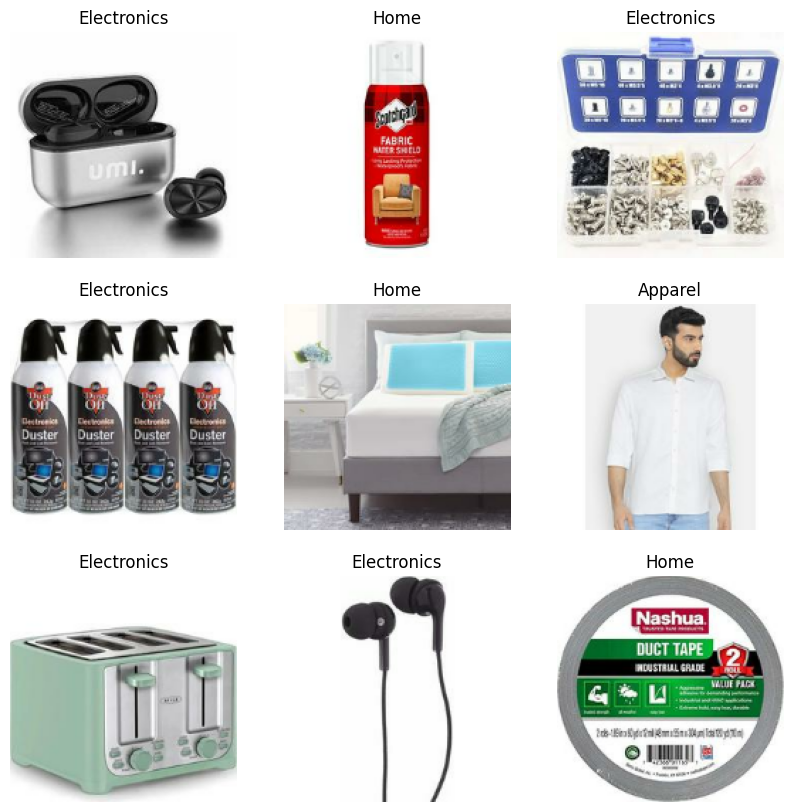

In [11]:
import matplotlib.pyplot as plt

# Count images per class in the training set
for i, name in enumerate(class_names):
    count = len(list(__import__("pathlib").Path(f"{DATA_DIR}/train/{name}").glob("*")))
    print(f"{name}: {count} images")

# Show a grid of sample images with their labels
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_idx = tf.argmax(labels[i]).numpy()
        plt.title(class_names[label_idx])
        plt.axis("off")

**If the class counts are wildly uneven** (say one class has 5x more images than another), tell me — we'll either trim the bigger classes down or use class weights during training so the model doesn't just learn to guess the biggest class.

## Step 4: Preprocessing

Two things happen here:
- **Normalization** — pixel values start as 0–255; neural networks train better when inputs are small numbers, so we rescale to 0–1.
- **Augmentation** — randomly flip/rotate/zoom training images each epoch, so the model sees slightly different versions each time instead of memorizing the exact same 1,000 photos. This is one of the simplest ways to fight overfitting on a smallish dataset.

In [12]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Cache + prefetch: speeds up training by preparing the next batch while the GPU is busy with the current one
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Preprocessing ready. Data pipeline set up for training.")

Preprocessing ready. Data pipeline set up for training.


## Next step

Run everything above. Check that:
1. `class_names` printed `['Apparel', 'Electronics', 'Home']` (order may vary — that's fine)
2. The sample image grid actually shows sensible photos with correct-looking labels
3. The per-class counts aren't wildly imbalanced

Once that's confirmed, come back and we'll build the actual CNN architecture next.

In [13]:
import pathlib

IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp"}

def count_images(folder):
    return sum(1 for p in pathlib.Path(folder).rglob("*") if p.suffix.lower() in IMG_EXTS)

for split in ["train", "val"]:
    print(f"--- {split} ---")
    for name in class_names:
        print(f"{name}: {count_images(f'{DATA_DIR}/{split}/{name}')} images")

# Make sure val isn't secretly a copy of train
for name in class_names:
    train_files = {p.name for p in pathlib.Path(f"{DATA_DIR}/train/{name}").rglob("*") if p.suffix.lower() in IMG_EXTS}
    val_files = {p.name for p in pathlib.Path(f"{DATA_DIR}/val/{name}").rglob("*") if p.suffix.lower() in IMG_EXTS}
    overlap = train_files & val_files
    print(f"{name}: {len(overlap)} filenames shared between train and val")

--- train ---
Apparel: 278 images
Electronics: 351 images
Home: 445 images
--- val ---
Apparel: 278 images
Electronics: 351 images
Home: 445 images
Apparel: 278 filenames shared between train and val
Electronics: 351 filenames shared between train and val
Home: 445 filenames shared between train and val


## Step 5: Build the CNN

Three "conv blocks" — each one Conv2D + MaxPooling — followed by a dense
classification head. Each block detects more complex patterns than the
last: edges → textures → shapes. Keeping it small on purpose: faster to
train on Colab's free GPU, and less likely to overfit on ~1,000 images.

We're plugging `data_augmentation` and `normalization_layer` (from Step 4)
in as the model's first layers, rather than applying them separately.
That way augmentation only kicks in during training (not validation),
and anyone who loads this saved model later gets the same preprocessing
automatically — no separate steps to remember.

In [14]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    data_augmentation,          # only active during training
    normalization_layer,        # scales pixels from 0-255 to 0-1

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),   # randomly disables 30% of neurons each step, to fight overfitting
    tf.keras.layers.Dense(num_classes, activation="softmax"),  # one probability per class, summing to 1
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",   # matches label_mode="categorical" from Step 2
    metrics=["accuracy"],
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,402,179 (20.61 MB)

 Trainable params: 5,402,179 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train

`EarlyStopping` watches validation accuracy and stops automatically if it
hasn't improved in 3 epochs, restoring the best weights seen — so you
don't have to guess the right number of epochs up front, and you don't
end up with an overfit final checkpoint.

In [15]:
EPOCHS = 20

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop],
)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.4058 - loss: 1.4486 - val_accuracy: 0.3505 - val_loss: 1.0708
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4209 - loss: 1.0585 - val_accuracy: 0.3505 - val_loss: 1.0353
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4872 - loss: 1.0199 - val_accuracy: 0.5280 - val_loss: 0.9787
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5128 - loss: 1.0025 - val_accuracy: 0.4720 - val_loss: 0.9536
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5244 - loss: 0.9434 - val_accuracy: 0.4065 - val_loss: 0.9873
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5419 - loss: 0.9406 - val_accuracy: 0.5234 - val_loss: 0.9248


In [16]:
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Final validation accuracy: {val_accuracy:.2%}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5280 - loss: 0.9787
Final validation accuracy: 52.80%


## Step 7: Transfer learning with MobileNetV2

Instead of learning to recognize edges/shapes/textures from scratch, we
reuse MobileNetV2 — a network already trained on 1.4 million images
(ImageNet). We freeze its learned layers (so we don't destroy that
knowledge) and only train a small new head on top for our 3 classes.
This is the standard fix when a from-scratch CNN underperforms on a
small dataset.

In [17]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,       # drop MobileNet's original 1000-class classifier
    weights="imagenet",
)
base_model.trainable = False  # freeze it — don't destroy what it already learned

model2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    data_augmentation,
    tf.keras.layers.Rescaling(1./127.5, offset=-1),  # MobileNetV2 expects pixels in [-1, 1], not [0, 1]
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
])

model2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model2.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 8: Train the transfer-learning model

In [18]:
EPOCHS = 15

early_stop2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
)

history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop2],
)

Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accuracy: 0.5465 - loss: 1.0519 - val_accuracy: 0.6308 - val_loss: 0.7789
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7000 - loss: 0.7299 - val_accuracy: 0.7664 - val_loss: 0.5736
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7500 - loss: 0.5771 - val_accuracy: 0.8084 - val_loss: 0.4629
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7907 - loss: 0.5159 - val_accuracy: 0.8318 - val_loss: 0.4481
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7930 - loss: 0.4800 - val_accuracy: 0.8271 - val_loss: 0.4352
Epoch 6/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8186 - loss: 0.4349 - val_accuracy: 0.8458 - val_loss: 0.4203
Epoch 7/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8465 - loss: 0.4058 - val_accuracy: 0.8318 - val_loss: 0.4041
Epoch 8/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8430 - loss: 0.4115 - val_accuracy: 0.8551 - 

In [19]:
val_loss, val_accuracy = model2.evaluate(val_ds)
print(f"Final validation accuracy: {val_accuracy:.2%}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8785 - loss: 0.3802
Final validation accuracy: 87.85%


## Step 9: Confusion matrix

87.85% overall accuracy hides where the remaining ~12% of mistakes are
concentrated. A confusion matrix shows exactly which categories get
mixed up with which — that's what lets a real catalogue team decide
which image types need manual review instead of trusting the model
blindly.

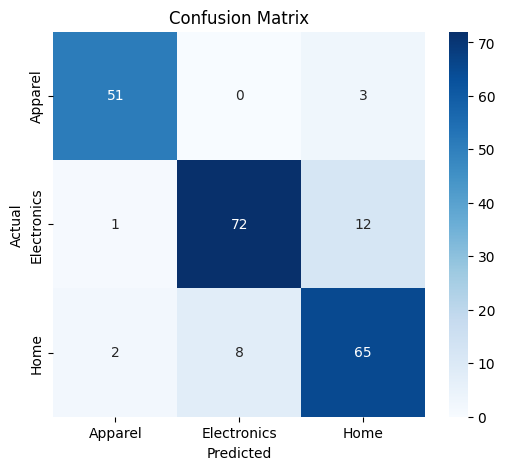

              precision    recall  f1-score   support

     Apparel       0.94      0.94      0.94        54
 Electronics       0.90      0.85      0.87        85
        Home       0.81      0.87      0.84        75

    accuracy                           0.88       214
   macro avg       0.89      0.89      0.89       214
weighted avg       0.88      0.88      0.88       214



In [20]:
import numpy as np
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model2.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))
y_true, y_pred = np.array(y_true), np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

os.makedirs("reports", exist_ok=True)
plt.savefig("reports/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [21]:
import itertools

confused_pairs = []
for i, j in itertools.product(range(len(class_names)), repeat=2):
    if i != j and cm[i][j] > 0:
        confused_pairs.append((class_names[i], class_names[j], cm[i][j]))
confused_pairs.sort(key=lambda x: -x[2])

print("Most confused category pairs (actual -> predicted):")
for actual, predicted, count in confused_pairs:
    print(f"  {actual} -> {predicted}: {count} images")

Most confused category pairs (actual -> predicted):
  Electronics -> Home: 12 images
  Home -> Electronics: 8 images
  Apparel -> Home: 3 images
  Home -> Apparel: 2 images
  Electronics -> Apparel: 1 images


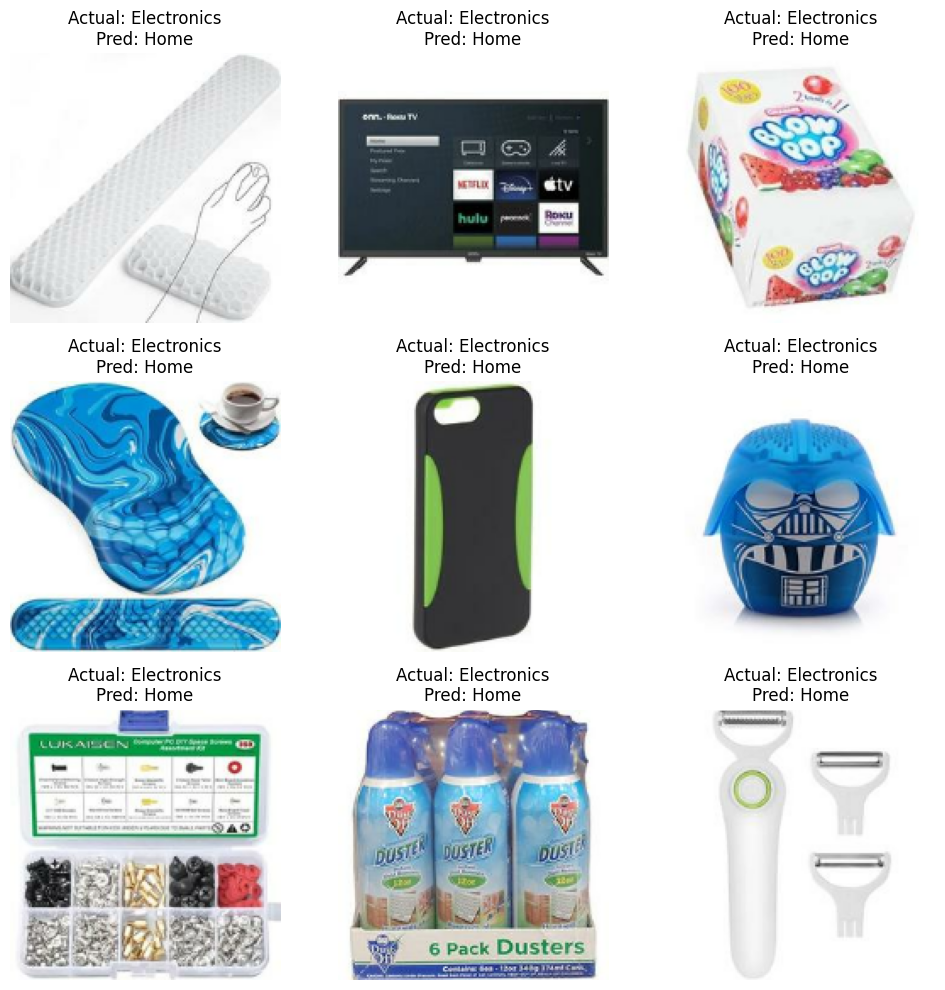

In [22]:
top_actual, top_predicted, _ = confused_pairs[0]
top_actual_idx = class_names.index(top_actual)
top_predicted_idx = class_names.index(top_predicted)

shown = 0
plt.figure(figsize=(10, 10))
for images, labels in val_ds:
    preds = model2.predict(images, verbose=0)
    true_idx = np.argmax(labels.numpy(), axis=1)
    pred_idx = np.argmax(preds, axis=1)
    for i in range(len(images)):
        if true_idx[i] == top_actual_idx and pred_idx[i] == top_predicted_idx and shown < 9:
            ax = plt.subplot(3, 3, shown + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(f"Actual: {top_actual}\nPred: {top_predicted}")
            plt.axis("off")
            shown += 1
    if shown >= 9:
        break
plt.tight_layout()
plt.show()

## Results

- **Validation accuracy:** 87.85% (transfer learning, MobileNetV2 base, frozen)
- **From-scratch CNN baseline:** approx. 53% — included to show why transfer learning was necessary on a dataset this size (roughly 860 training images)

### Per-class performance
| Class | Precision | Recall | F1 |
|---|---|---|---|
| Apparel | 0.94 | 0.94 | 0.94 |
| Electronics | 0.90 | 0.85 | 0.87 |
| Home | 0.81 | 0.87 | 0.84 |

### Where it fails
Electronics ↔ Home accounts for 77% of all misclassifications (20 of 26 errors), while Apparel is rarely confused with either. Inspecting the actual misclassified images points to three causes:
1. **Small accessories with no distinctive visual signature** (phone cases, cable organizers) — no screens, wires, or buttons to key off of.
2. **Camouflaged electronics** — devices shaped like toys/decor (e.g. a novelty-shaped Bluetooth speaker) visually read as home items.
3. **Genuine taxonomy ambiguity** — small kitchen appliances (mixers, kettles) are simultaneously "Home" (used in a kitchen) and "Electronics" (have a motor/plug), a real-world overlap no classifier fully resolves.
4. A data-quality check also surfaced at least one source-label error (a candy product tagged "Electronics"), suggesting the achievable ceiling is somewhat below 100% regardless of model quality.

**Recommendation:** route predictions in the Electronics/Home boundary with low model confidence to manual review; Apparel predictions can be trusted with minimal spot-checking.

![Confusion Matrix](https://github.com/abazzzdeep/product-image-classifier/blob/main/notebooks/reports/confusion_matrix.png?raw=1)